
0: 640x480 1 Chinese One Yuan Coin, 1 Japanese Fifty Yen Coin, 1 Japanese One Yen Coin, 1 Philippine One Peso Coin, 3 Thailand Five Baht Coins, 3 Thailand One Baht Coins, 30.7ms
Speed: 2.2ms preprocess, 30.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)


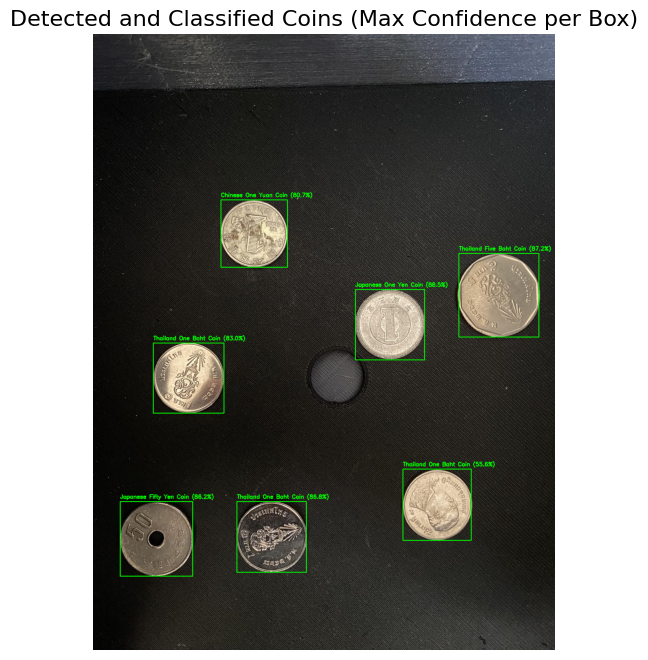

✅ Output saved at: E:\Downloads\matrix\output_test.jpg


In [5]:
import torch
import cv2
import numpy as np
from ultralytics import YOLO
from timm import create_model
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import os

# ====================
# CONFIG
# ====================
yolo_model_path = r"E:\Coins\Coin Classification.v7i.yolov8\yolov8_coin_model_retrain\weights\best.pt"
rcnn_model_path = r"E:\Coins\Retrained_Model\best_model.pth"
test_image_path = r"E:\Downloads\483528861_9383459598396769_1726034168435562489_n.jpg"

output_dir = r"E:\Downloads\matrix"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "output_test.jpg")

MIN_CONFIDENCE = 0.50
IOU_THRESHOLD = 0.5  # Overlap threshold for removing duplicates

# Class labels
class_names = [
    'Chinese One Yuan Coin', 'Japanese Fifty Yen Coin',
    'Japanese Five Hundred Coin', 'Japanese Five Yen Coin', 'Japanese One Hundred Yen Coin',
    'Japanese One Yen Coin', 'Japanese Ten Yen Coin', 'Korean Fifty Won Coin',
    'Korean Five Hundred Won Coin', 'Korean One Hundred Won Coin', 'Korean Ten Won Coin',
    'Philippine Five Peso Coin', 'Philippine One Peso Coin', 'Philippine Ten Peso Coin',
    'Thailand Five Baht Coin', 'Thailand One Baht Coin', 'Thailand Ten Baht Coin'
]

# ====================
# MODELS
# ====================
yolo_model = YOLO(yolo_model_path)

class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model("efficientnet_b2", pretrained=False, num_classes=0, global_pool='')
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rcnn_model = CustomEfficientNet(num_classes=len(class_names)).to(device)
rcnn_model.load_state_dict(torch.load(rcnn_model_path, map_location=device))
rcnn_model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ====================
# FUNCTIONS
# ====================
def iou(box1, box2):
    """Compute IoU between two boxes: [x1, y1, x2, y2]"""
    xi1, yi1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    xi2, yi2 = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area != 0 else 0

def non_max_suppression_classified(detections, iou_threshold):
    """Perform NMS based on classification confidence"""
    detections = sorted(detections, key=lambda x: x["confidence"], reverse=True)
    keep = []
    while detections:
        best = detections.pop(0)
        keep.append(best)
        detections = [
            d for d in detections
            if iou(best["box"], d["box"]) < iou_threshold
        ]
    return keep

# ====================
# PROCESS IMAGE
# ====================
frame = cv2.imread(test_image_path)
if frame is None:
    raise FileNotFoundError(f"Image not found: {test_image_path}")

results = yolo_model(frame)[0]

detections = []
for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    coin_crop = frame[y1:y2, x1:x2]

    if coin_crop.size == 0:
        continue

    image = cv2.cvtColor(coin_crop, cv2.COLOR_BGR2RGB)
    image = transform(Image.fromarray(image)).unsqueeze(0).to(device)

    with torch.no_grad():
        output = rcnn_model(image)
        pred = torch.argmax(output, dim=1).item()
        confidence = torch.softmax(output, dim=1)[0][pred].item()

    if confidence >= MIN_CONFIDENCE:
        detections.append({
            "box": [x1, y1, x2, y2],
            "label": f"{class_names[pred]} ({confidence*100:.1f}%)",
            "confidence": confidence
        })

# Apply NMS so only the highest-confidence label per overlapping box is kept
final_detections = non_max_suppression_classified(detections, IOU_THRESHOLD)

# Draw results
output_frame = frame.copy()
for det in final_detections:
    x1, y1, x2, y2 = det["box"]
    cv2.rectangle(output_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(output_frame, det["label"], (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# ====================
# SAVE & DISPLAY
# ====================
cv2.imwrite(output_path, output_frame)

output_rgb = cv2.cvtColor(output_frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(output_rgb)
plt.axis("off")
plt.title("Detected and Classified Coins (Max Confidence per Box)", fontsize=16)
plt.show()

print(f"✅ Output saved at: {output_path}")


Using device: cuda
Loading YOLOv8 model...
Loading RCNN model...
Detected 19 classes:
0: Chinese One Yuan Coin
1: Japanese Fifty Yen Coin
2: Japanese Five Hundred Yen Coin
3: Japanese Five Yen Coin
4: Japanese One Hundred Yen Coin
5: Japanese One Yen Coin
6: Japanese Ten Yen Coin
7: Korean Fifty Won Coin
8: Korean Five Hundred Won Coin
9: Korean Five Won Coin
10: Korean One Hundred Won Coin
11: Korean One Won Coin
12: Korean Ten Won Coin
13: Philippine Five Peso Coin
14: Philippine One Peso Coin
15: Philippine Ten Peso Coin
16: Thailand Five Baht Coin
17: Thailand One Baht Coin
18: Thailand Ten Baht Coin
Processing image...

0: 640x640 1 Japanese Fifty Yen Coin, 1 Japanese Five Hundred Coin, 1 Japanese Five Yen Coin, 1 Japanese One Hundred Yen Coin, 2 Japanese Ten Yen Coins, 2 Thailand One Baht Coins, 27.1ms
Speed: 3.8ms preprocess, 27.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


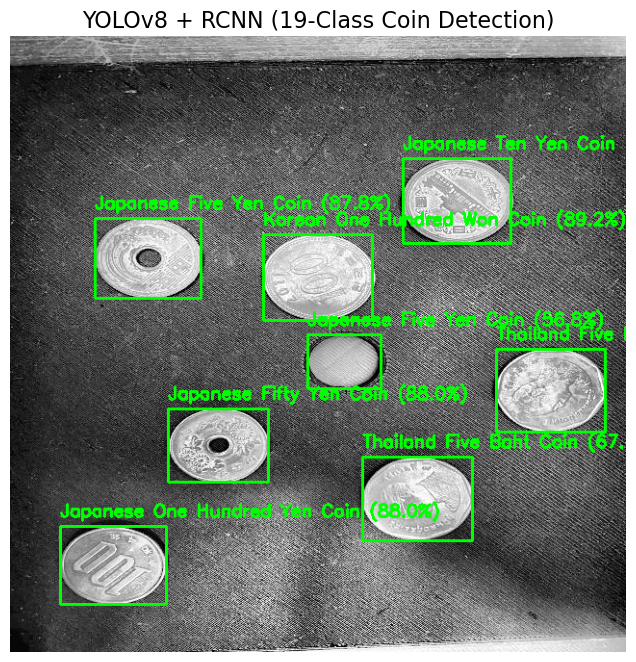


✅ Output saved at: E:\Coins\Coin Classification.v8i.yolov8\output_19class.jpg


In [4]:
import torch
import cv2
import numpy as np
from ultralytics import YOLO
from timm import create_model
import torch.nn as nn
from torchvision import transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt
import os

# ===============================
# CONFIG
# ===============================
yolo_model_path = r"C:\Users\silva\runs\detect\train19\weights\best.pt"
rcnn_model_path = r"E:\Coins\Coin Classification.v8i.yolov8\best_model_19classes.pth"
train_dir = r"E:\Coins\New_Dataset_V2\train"   # used only to load class names
test_image_path = r"E:\Coins\Coin Classification.v8i.yolov8\test\images\486230548_1852060418878111_4629068351698793940_n_jpg.rf.1cfeacc4cdb1e6de24333f032f8329d8.jpg"

output_dir = r"E:\Coins\Coin Classification.v8i.yolov8"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "output_19class.jpg")

YOLO_CONF_THRESHOLD = 0.25
RCNN_CONF_THRESHOLD = 0.50
IOU_THRESHOLD = 0.5

# ===============================
# DEVICE
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===============================
# LOAD YOLO MODEL
# ===============================
print("Loading YOLOv8 model...")
yolo_model = YOLO(yolo_model_path)

# ===============================
# LOAD RCNN MODEL
# ===============================
print("Loading RCNN model...")

# Load class names dynamically (important for correct order)
dummy_dataset = datasets.ImageFolder(train_dir)
class_names = dummy_dataset.classes
num_classes = len(class_names)

print("Detected 19 classes:")
for i, name in enumerate(class_names):
    print(f"{i}: {name}")

class CustomEfficientNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = create_model(
            "efficientnet_b2",
            pretrained=False,
            num_classes=0,
            global_pool=''
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1408, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.head(x)

rcnn_model = CustomEfficientNet(num_classes).to(device)
state_dict = torch.load(rcnn_model_path, map_location=device, weights_only=True)
rcnn_model.load_state_dict(state_dict)
rcnn_model.eval()

# ===============================
# TRANSFORM
# ===============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ===============================
# IOU + NMS
# ===============================
def iou(box1, box2):
    xi1, yi1 = max(box1[0], box2[0]), max(box1[1], box2[1])
    xi2, yi2 = min(box1[2], box2[2]), min(box1[3], box2[3])
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area != 0 else 0

def non_max_suppression_classified(detections, iou_threshold):
    detections = sorted(detections, key=lambda x: x["confidence"], reverse=True)
    keep = []
    while detections:
        best = detections.pop(0)
        keep.append(best)
        detections = [
            d for d in detections
            if iou(best["box"], d["box"]) < iou_threshold
        ]
    return keep

# ===============================
# PROCESS IMAGE
# ===============================
print("Processing image...")
frame = cv2.imread(test_image_path)

if frame is None:
    raise FileNotFoundError("Test image not found.")

results = yolo_model(frame, conf=YOLO_CONF_THRESHOLD)[0]

detections = []

for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    coin_crop = frame[y1:y2, x1:x2]
    if coin_crop.size == 0:
        continue

    image = cv2.cvtColor(coin_crop, cv2.COLOR_BGR2RGB)
    image = transform(Image.fromarray(image)).unsqueeze(0).to(device)

    with torch.no_grad():
        output = rcnn_model(image)
        probabilities = torch.softmax(output, dim=1)
        confidence, pred = torch.max(probabilities, 1)

    confidence = confidence.item()
    pred_class = class_names[pred.item()]

    if confidence >= RCNN_CONF_THRESHOLD:
        detections.append({
            "box": [x1, y1, x2, y2],
            "label": f"{pred_class} ({confidence*100:.1f}%)",
            "confidence": confidence
        })

# Apply NMS
final_detections = non_max_suppression_classified(detections, IOU_THRESHOLD)

# ===============================
# DRAW OUTPUT
# ===============================
output_frame = frame.copy()

for det in final_detections:
    x1, y1, x2, y2 = det["box"]

    cv2.rectangle(output_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    cv2.putText(
        output_frame,
        det["label"],
        (x1, max(30, y1 - 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

# ===============================
# SAVE & DISPLAY
# ===============================
cv2.imwrite(output_path, output_frame)

output_rgb = cv2.cvtColor(output_frame, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(output_rgb)
plt.axis("off")
plt.title("YOLOv8 + RCNN (19-Class Coin Detection)", fontsize=16)
plt.show()

print(f"\n✅ Output saved at: {output_path}")